In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("submission.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Submission shape: {submission.shape}")

Train shape: (18272, 3)
Test shape:  (4, 2)
Submission shape: (10, 2)


In [5]:
print("\n=== Train info ===")
print(train.dtypes)
print(f"\nNull counts:\n{train.isnull().sum()}")

print("\n=== Test info ===")
print(test.dtypes)
print(f"\nNull counts:\n{test.isnull().sum()}")


=== Train info ===
ID        object
report    object
target     int64
dtype: object

Null counts:
ID        0
report    0
target    0
dtype: int64

=== Test info ===
ID        object
report    object
dtype: object

Null counts:
ID        0
report    0
dtype: int64



=== Target (BI-RADS) distribution ===
target
0      610
1      693
2    15968
3      713
4      214
5       29
6       45
Name: count, dtype: int64

Target proportions:
target
0    0.033384
1    0.037927
2    0.873905
3    0.039021
4    0.011712
5    0.001587
6    0.002463
Name: count, dtype: float64


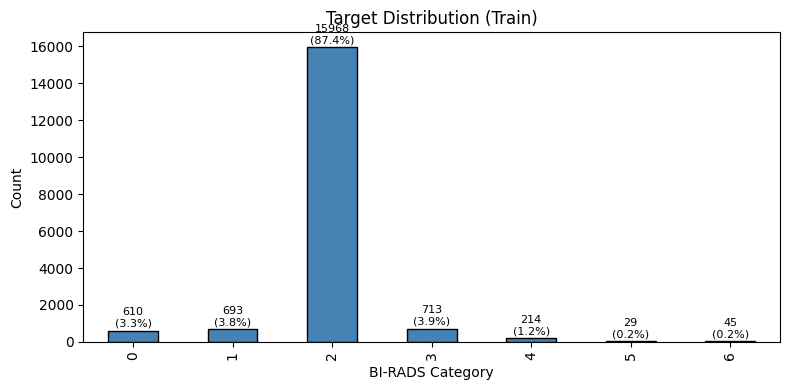

In [6]:
print("\n=== Target (BI-RADS) distribution ===")
target_counts = train["target"].value_counts().sort_index()
print(target_counts)
print(f"\nTarget proportions:\n{target_counts / len(train)}")

fig, ax = plt.subplots(figsize=(8, 4))
target_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("BI-RADS Category")
ax.set_ylabel("Count")
ax.set_title("Target Distribution (Train)")
for i, (cat, count) in enumerate(target_counts.items()):
    ax.text(i, count + len(train) * 0.005, f"{count}\n({count/len(train)*100:.1f}%)",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
train["report_len"] = train["report"].str.len()
train["report_words"] = train["report"].str.split().apply(len)

test["report_len"] = test["report"].str.len()
test["report_words"] = test["report"].str.split().apply(len)

print("\n=== Report length (chars) ===")
print(train["report_len"].describe())

print("\n=== Report length (words) ===")
print(train["report_words"].describe())


=== Report length (chars) ===
count    18272.000000
mean       400.666594
std        103.232834
min        183.000000
25%        332.000000
50%        364.000000
75%        423.000000
max       1622.000000
Name: report_len, dtype: float64

=== Report length (words) ===
count    18272.000000
mean        44.896618
std         14.217563
min         19.000000
25%         36.000000
50%         40.000000
75%         48.000000
max        234.000000
Name: report_words, dtype: float64


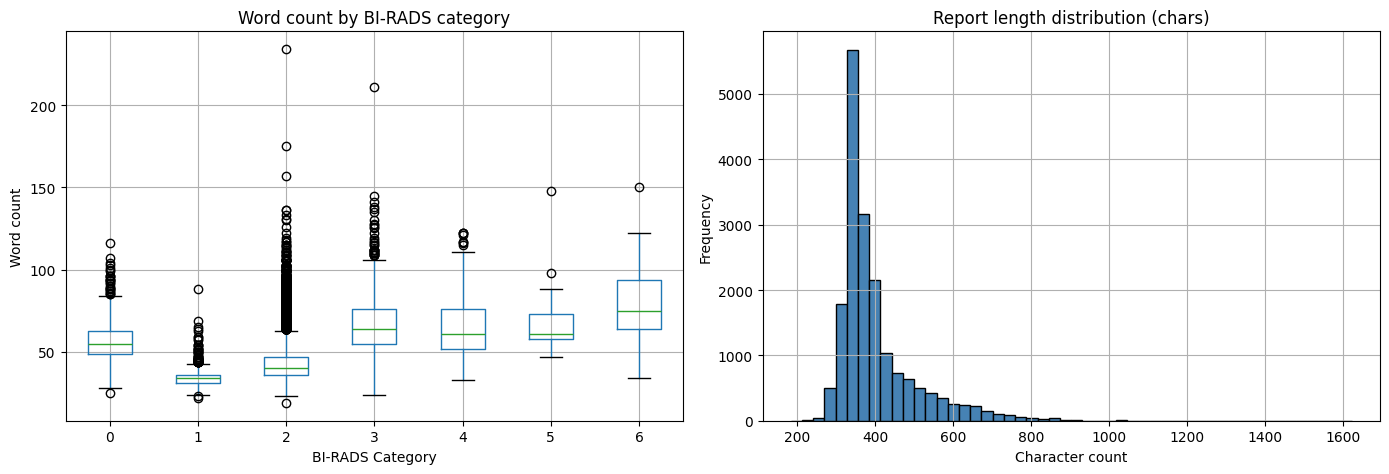

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train.boxplot(column="report_words", by="target", ax=axes[0])
axes[0].set_title("Word count by BI-RADS category")
axes[0].set_xlabel("BI-RADS Category")
axes[0].set_ylabel("Word count")

train["report_len"].hist(bins=50, ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Report length distribution (chars)")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Frequency")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [9]:
for cat in sorted(train["target"].unique()):
    print(f"\n{'='*60}")
    print(f"BI-RADS {cat} — Sample report:")
    print("=" * 60)
    sample = train[train["target"] == cat].iloc[0]
    print(sample["report"][:500])
    print("...")


BI-RADS 0 — Sample report:
Indicação clínica:
 reavaliação de alteração observada à mamografia de <DATA>.
Realizadas incidências compressão craniocaudal e perfil ( com compressão localizada) na mama esquerda.
Achados:
Calcificações benignas esparsas.
Assimetria focal localizada no quadrante superolateral da mama esquerda, melhor visualizado na incidência craniocaudal, que muda de configuração nas diversas incidências.

...

BI-RADS 1 — Sample report:
Indicação clínica:
 reavaliação de alteração observada à mamografia de <DATA>Realizadas incidências com compressão localizada na mama esquerda.
Achados:
Assimetria focal localizada na projeção dos quadrantes laterais da mama esquerda, que após estudo com compressão seletiva, não evidencia nódulo ou distorção arquitetural, podendo ser caracterizada como área de tecido fibroglandular residual.

...

BI-RADS 2 — Sample report:
Indicação clínica:
 rastreamento.
Achados:
Mamas parcialmente lipossubstituídas.
Calcificações benignas esparsas.
Nã

In [10]:
print("\n=== Language sample (first 5 reports) ===")
for _, row in train.head(5).iterrows():
    snippet = row["report"][:80].replace("\n", " ")
    print(f"  [{row['ID']}] {snippet}...")

# %% --- Check for duplicate reports ---
n_dupes = train["report"].duplicated().sum()
print(f"\nDuplicate reports in train: {n_dupes} ({n_dupes/len(train)*100:.2f}%)")


# %% --- Check test/train overlap ---
overlap = set(test["ID"]) & set(train["ID"])
print(f"ID overlap between train and test: {len(overlap)}")

report_overlap = set(test["report"]) & set(train["report"])
print(f"Report text overlap between train and test: {len(report_overlap)}")

# %% --- Submission sanity check ---
print(f"\nSubmission IDs match test IDs: {set(submission['ID']) == set(test['ID'])}")
print(f"Submission target placeholder values: {submission['target'].unique()}")

# %% --- Cleanup temp columns ---
train.drop(columns=["report_len", "report_words"], inplace=True)
test.drop(columns=["report_len", "report_words"], inplace=True)

print("\nDone! Data inspection complete.")


=== Language sample (first 5 reports) ===
Mamas parcialmente lipossubstituíd...
Mamas parcialmente lipossubstituíd...
Mamas parcialmente lipossubstituíd...
 reavaliação de alteração observada à mamografia de <DATA>. ...
 reavaliação de alteração observada à mamografia de <DATA>. ...

Duplicate reports in train: 9141 (50.03%)
ID overlap between train and test: 0
Report text overlap between train and test: 0

Submission IDs match test IDs: False
Submission target placeholder values: [-1]

Done! Data inspection complete.


In [11]:
train_cleaned = train.drop_duplicates(subset=["report", "target"]).reset_index(drop=True)
print(f"Before: {len(train)} rows")
print(f"After:  {len(train_cleaned)} rows")
print(f"Removed: {len(train) - len(train_cleaned)} duplicates")
print(f"\nTarget distribution after dedup:")
print(train_cleaned["target"].value_counts().sort_index())

Before: 18272 rows
After:  9142 rows
Removed: 9130 duplicates

Target distribution after dedup:
target
0     604
1     242
2    7296
3     712
4     214
5      29
6      45
Name: count, dtype: int64


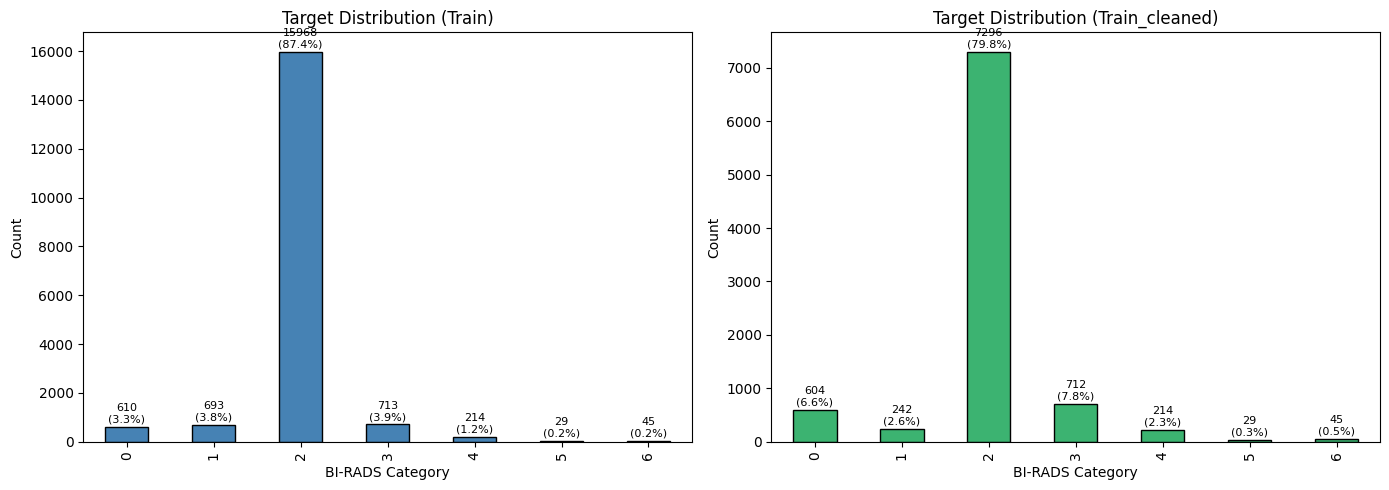

In [12]:
# Compute value counts for each dataset
target_counts_train = train["target"].value_counts().sort_index()
target_counts_cleaned = train_cleaned["target"].value_counts().sort_index()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original train set distribution
target_counts_train.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_xlabel("BI-RADS Category")
axes[0].set_ylabel("Count")
axes[0].set_title("Target Distribution (Train)")
for i, (cat, count) in enumerate(target_counts_train.items()):
    axes[0].text(i, count + len(train) * 0.005, f"{count}\n({count / len(train) * 100:.1f}%)",
                 ha="center", va="bottom", fontsize=8)

# Cleaned train set distribution
target_counts_cleaned.plot(kind="bar", ax=axes[1], color="mediumseagreen", edgecolor="black")
axes[1].set_xlabel("BI-RADS Category")
axes[1].set_ylabel("Count")
axes[1].set_title("Target Distribution (Train_cleaned)")
for i, (cat, count) in enumerate(target_counts_cleaned.items()):
    axes[1].text(i, count + len(train_cleaned) * 0.005, f"{count}\n({count / len(train_cleaned) * 100:.1f}%)",
                 ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
import re
_whitespace_re = re.compile(r"[ \t]+")
_newlines_re = re.compile(r"\n{2,}")


def clean_text(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = s.replace("\r\n", "\n").replace("\r", "\n")
    s = _whitespace_re.sub(" ", s)
    s = _newlines_re.sub("\n", s)
    return s

In [14]:
train_cleaned["text"] = train_cleaned["report"].apply(clean_text)
train_cleaned.head()

,ID,report,target,text
0,Acc1,Indicação clínica:\n\r rastreamento.\n\rAchado...,2,indicação clínica:\n rastreamento.\nachados:\n...
1,Acc3,Indicação clínica:\n\r rastreamento.\n\rAchado...,2,indicação clínica:\n rastreamento.\nachados:\n...
2,Acc5,Indicação clínica:\n\r rastreamento.\n\rAchado...,2,indicação clínica:\n rastreamento.\nachados:\n...
3,Acc6,Indicação clínica:\n\r reavaliação de alteraçã...,2,indicação clínica:\n reavaliação de alteração ...
4,Acc7,Indicação clínica:\n\r reavaliação de alteraçã...,2,indicação clínica:\n reavaliação de alteração ...
